In [1]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

In [14]:
month = '7'
with rasterio.open(f"/Users/cherryleheu/Documents/HCDP/Data/climo/monthly/tmean/monthly_air_temp_clim_statewide_1991-2020_{month}.tif") as src:
    temp_climo = src.read(1)
    nodata_climo = src.nodata
    meta = src.meta.copy()

masked_climo = np.ma.masked_equal(temp_climo, nodata_climo)

with rasterio.open(f"/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/tmean_2025_0{month}.tif") as src:
    temp = src.read(1)
    nodata_temp = src.nodata
    transform = src.transform

masked_temp= np.ma.masked_equal(temp, nodata_temp)

diff = (masked_temp - masked_climo)

combined_mask = np.ma.getmask(masked_temp) | np.ma.getmask(masked_climo)
pdiff_masked = np.ma.array(diff, mask=combined_mask)

out_nodata = -9999 
meta.update(
    dtype="float32",
    nodata=out_nodata
)

with rasterio.open(f"../public/tifs/tmean_diff_2025_0{month}.tif", "w", **meta) as dst:
    dst.write(pdiff_masked.filled(out_nodata).astype("float32"), 1)


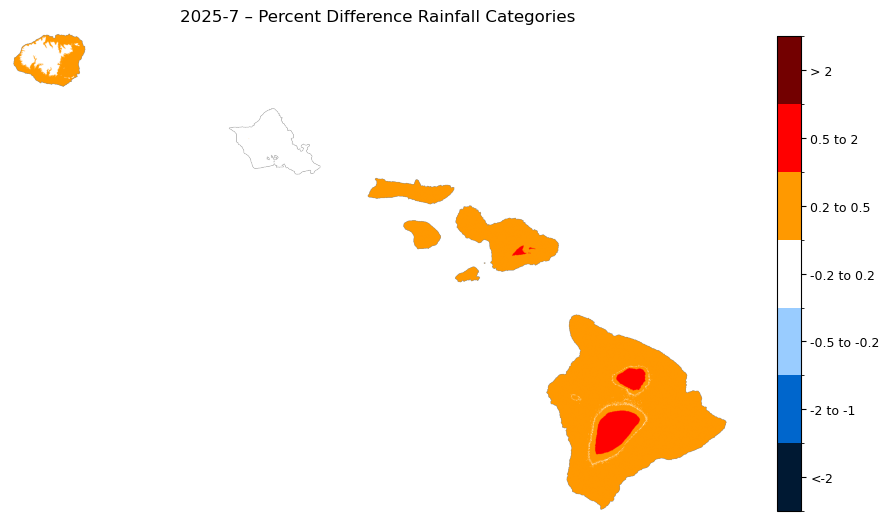

In [15]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -2, "#001933", "<-2"),
    (-2, -0.5, "#0066CC", "-2 to -1"),
    (-0.5, -0.2, "#99CCFF", "-0.5 to -0.2"),
    (-0.2, 0.2, "#FFFFFF", "-0.2 to 0.2"),
    (0.2, 0.5, "#FF9900", "0.2 to 0.5"),
    (0.5, 2, "#FF0000", "0.5 to 2"),
    (2, np.inf, "#730000", "> 2"),
]

with rasterio.open(f"../public/tifs/tmean_diff_2025_0{month}.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open(f"../public/tifs/tmean_diff_cat_0{month}.tif", "w", **profile) as dst:
    dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.title(f"2025-{month} – Percent Difference Rainfall Categories")
plt.tight_layout()
plt.show()
